### Predictive Analysis — Healthcare Appointment No-show Prediction

This notebook builds and compares three predictive models — Logistic Regression, Decision Tree and Random Forest — to answer a forward-looking question:

> **Business question:** Given information available before an appointment happens, can predictive modeling solve patient no-show problem?

**Target definition**:
- `No-show` → **1**
- `Completed` or `Cancelled` → **0**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Preprocessing
### 1. Load the Clean Dataset

The cleaned dataset (`data/appointments_clean.csv`) already has Title Case column names,
derived columns (`Age Group`, `Day of Week`, `Day Type`), and the binary `No Show Flag`
target this project needs precomputed. This notebook loads that file directly.

`No Show Flag` is defined the same way the Stage 1 no-show-rate analysis defines a no-show:
`Appointment Status == 'No-show'` → `1`, otherwise → `0`.


In [2]:
df = pd.read_csv('../data/appointments_clean.csv', parse_dates=['Appointment Date'])

print("=== Dataset Overview ===")
print(f"Rows, Columns : {df.shape}")
print(f"Date Range    : {df['Appointment Date'].min().date()} → {df['Appointment Date'].max().date()}\n")

print("=== Columns & Types ===")
print(df.dtypes)

df.head()

=== Dataset Overview ===
Rows, Columns : (500, 12)
Date Range    : 2023-01-02 → 2024-12-26

=== Columns & Types ===
Age                            int64
Gender                        object
Division                      object
Doctor Specialty              object
Appointment Status            object
Consultation Fee               int64
Wait Days                      int64
Appointment Date      datetime64[ns]
Age Group                     object
Day of Week                   object
Day Type                      object
No Show Flag                   int64
dtype: object


,Age,Gender,Division,Doctor Specialty,Appointment Status,Consultation Fee,Wait Days,Appointment Date,Age Group,Day of Week,Day Type,No Show Flag
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19,Senior (56+),Sunday,Weekday,0
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07,Young Adult (18-35),Friday,Weekend,0
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27,Senior (56+),Monday,Weekday,0
3,65,Male,Chattogram,Cardiologist,Completed,1492,20,2024-03-17,Senior (56+),Sunday,Weekday,0
4,25,Male,Dhaka,Orthopedic,Cancelled,1331,16,2023-04-06,Young Adult (18-35),Thursday,Weekday,0


### 2. Feature Engineering 

The raw date itself isn't a usable model input (a `LogisticRegression` can't do anything
meaningful with a timestamp). Instead, two interpretable and recurring signals were extracted from it:

- Quarter (Q1–Q4) — captures coarse seasonal patterns, such as holiday periods and weather-related trends.
- Month Name (January–December) — captures monthly seasonality and recurring patterns in appointment demand.


In [3]:
BD_WEEKEND_DAYS = {'Friday', 'Saturday'} 

df['Quarter'] = 'Q' + df['Appointment Date'].dt.quarter.astype(str)
df['Month Name'] = df['Appointment Date'].dt.month_name()

print("=== Sample of engineered date features ===")
df[['Appointment Date', 'Quarter', 'Month Name']].head(8)

=== Sample of engineered date features ===


,Appointment Date,Quarter,Month Name
0,2023-11-19,Q4,November
1,2024-06-07,Q2,June
2,2023-02-27,Q1,February
3,2024-03-17,Q1,March
4,2023-04-06,Q2,April
5,2023-11-19,Q4,November
6,2024-05-24,Q2,May
7,2023-09-06,Q3,September


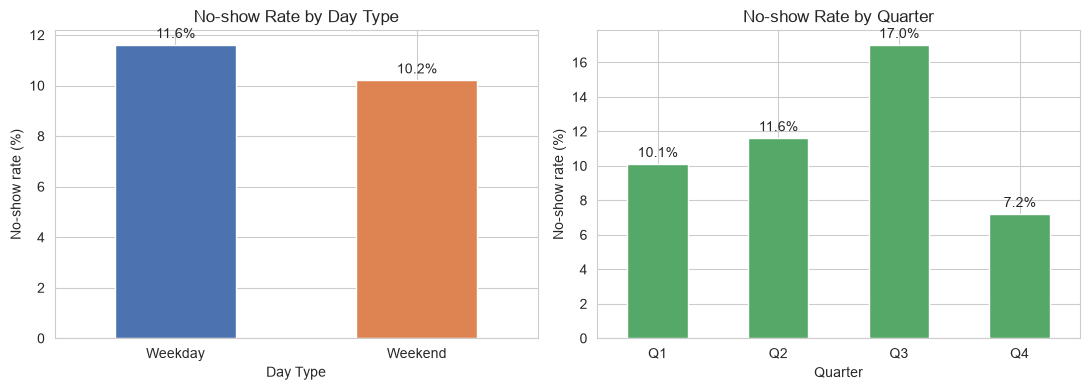

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

day_type_rate = df.groupby('Day Type')['No Show Flag'].mean().mul(100).round(1)
day_type_rate.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=3)
axes[0].set_title('No-show Rate by Day Type')
axes[0].set_ylabel('No-show rate (%)')
axes[0].tick_params(axis='x', rotation=0)

quarter_rate = df.groupby('Quarter')['No Show Flag'].mean().mul(100).round(1).sort_index()
quarter_rate.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
axes[1].set_title('No-show Rate by Quarter')
axes[1].set_ylabel('No-show rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3. Feature Selection

**Data leakage** happens when a feature contains information that wouldn't actually be
available *before* the event is being predicting — the model looks accurate in testing but is
useless in production because that information doesn't exist yet at prediction time.

Going through every column in the clean dataset:

| Column | Use as a feature? | Reason |
|---|---|---|
| `Appointment Status` | ❌ **Excluded** | This is literally how the target was built (`No Show Flag`). Using it as a feature would leak the answer directly — the model would just learn "No-show" → predict No-show. |
| `No Show Flag` | ❌ Target, not a feature | What will be predicted. |
| `Consultation Fee` | ❌ **Excluded per project requirement** | Excluded deliberately for this stage. As a side note, it's also almost a 1:1 stand-in for `Doctor Specialty` (each specialty has a near-fixed fee band), so keeping both would add redundant. |
| `Appointment Date` (raw) | ❌ Excluded | Replaced by the engineered `Quarter` / `Day of Week` / `Day Type` features above. |
| `Age` | ❌ Excluded | Keeping both `Age` and `Age Group` would be redundant |
| `Age Group` | ✅ Included | Known at booking time. Directly derived from `Age` |
| `Gender` | ✅ Included | Known at booking time. |
| `Division` | ✅ Included | Known at booking time. |
| `Doctor Specialty` | ✅ Included | Known at booking time. |
| `Wait Days` | ✅ Included | This is the gap between *booking* and the *appointment date*, so during appointment date it will help to determine whether the patient will show up or not. |
| `Quarter`, `Day of Week`, `Day Type`, `Month Name` | ✅ Included | Derived from the appointment date, which is scheduled in advance. |


In [5]:
categorical_features = [
    'Gender', 'Division', 'Doctor Specialty', 'Month Name',
    'Quarter', 'Day of Week', 'Day Type', 'Age Group'
]
numerical_features = ['Wait Days']

feature_cols = categorical_features + numerical_features

X = df[feature_cols]
Y = df['No Show Flag']

print("Final feature set:")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical   ({len(numerical_features)}): {numerical_features}")
print(f"\nX shape: {X.shape}   Y shape: {Y.shape}")


Final feature set:
  Categorical (8): ['Gender', 'Division', 'Doctor Specialty', 'Month Name', 'Quarter', 'Day of Week', 'Day Type', 'Age Group']
  Numerical   (1): ['Wait Days']

X shape: (500, 9)   Y shape: (500,)


### 4. Train/Test Split 

With only 56 no-show cases in 500 rows, a plain random split risks putting very few no-shows in the test set purely by chance. **`stratify=y`** forces
both the train and test sets to preserve the same ~11.2% no-show ratio as the full dataset, so
the test-set evaluation is a fair reflection of the real class balance.

Splitting is done **before** any encoding or scaling, so the encoder and scaler only ever learn from training data — never from the test set.


In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} rows  |  Test set: {X_test.shape[0]} rows\n")

print("Train target balance:")
print(Y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print("\nTest target balance:")
print(Y_test.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f"\nNo-show cases in test set: {Y_test.sum()} out of {len(Y_test)}")


Train set: 400 rows  |  Test set: 100 rows

Train target balance:
No Show Flag
0    88.8%
1    11.2%
Name: proportion, dtype: object

Test target balance:
No Show Flag
0    89.0%
1    11.0%
Name: proportion, dtype: object

No-show cases in test set: 11 out of 100


### 5. Preprocessing + Model Pipeline (`ColumnTransformer` + `Pipeline`)

Two preprocessing choices for Logistic Regression specifically:

- **One-hot encoding** for all categorical (nominal) features — Logistic Regression needs
  numeric input, and these categories have no natural order (there's no sense in which
  `Division = Dhaka` is "more" than `Division = Khulna`). `drop='first'` drops one category per
  feature as a **reference/baseline level**.
- **Standard scaling** for the one numeric feature (`Wait Days`) — Scaling puts numerical features on comparable scales and generally makes the optimization process more stable and efficient when learning the coefficients of the equation.

**Avoiding preprocessing leakage:** The encoder and scaler are fitted only on the training data. The test data is then transformed using what was learned from the training data. This prevents information from the test set from influencing the model during training.



In [7]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features),
])

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

lr_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## Model Training

In [8]:
lr_model.fit(X_train, Y_train)
print("Model trained.")

Model trained.


## Learned Coefficients — How to Interpret Them

Logistic Regression learns a coefficient for each feature. These coefficients are used in the z equation to calculate the final probability of No-show.

- Positive coefficient (+) → the feature is associated with higher odds of No-show, while keeping other features constant.
- Negative coefficient (−) → the feature is associated with lower odds of No-show.
- Larger absolute coefficient → stronger effect on the model's calculated odds, although coefficient size should be interpreted carefully across different feature types/scales.

For categorical features, each category is compared with its reference (baseline) category. For example, the reference category for `Doctor Specialty` is **Cardiologist** (see the reference categories printed below). So:

Gynecologist coefficient = −0.669 → Gynecologist appointments have lower predicted odds of No-show compared with Cardiologist, holding other features constant.

For scaled numerical features, the coefficient represents the change associated with a one-standard-deviation increase in that variable.



In [9]:
# Reference (dropped) category per categorical feature
fitted_ohe = lr_model.named_steps['preprocessor'].named_transformers_['cat']
print("=== Reference category per feature (dropped by drop='first') ===")
for feat, cats in zip(categorical_features, fitted_ohe.categories_):
    print(f"  {feat:20s} → reference: {cats[0]}")

=== Reference category per feature (dropped by drop='first') ===
  Gender               → reference: Female
  Division             → reference: Barishal
  Doctor Specialty     → reference: Cardiologist
  Month Name           → reference: April
  Quarter              → reference: Q1
  Day of Week          → reference: Friday
  Day Type             → reference: Weekday
  Age Group            → reference: Child (0-17)


In [10]:
feature_names = lr_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('cat__', '').replace('num__', '') for f in feature_names]

coefs = lr_model.named_steps['classifier'].coef_[0]
intercept = lr_model.named_steps['classifier'].intercept_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).reset_index(drop=True)

coef_df

,feature,coefficient
0,Age Group_Young Adult (18-35),-1.100788
1,Division_Rangpur,-0.672319
2,Day of Week_Wednesday,-0.655782
3,Doctor Specialty_Gynecologist,-0.555719
4,Month Name_September,0.530029
5,Day of Week_Monday,0.495026
6,Doctor Specialty_Pediatrician,0.492266
7,Quarter_Q3,0.463236
8,Month Name_May,0.456595
9,Age Group_Middle Age (36-55),-0.434455


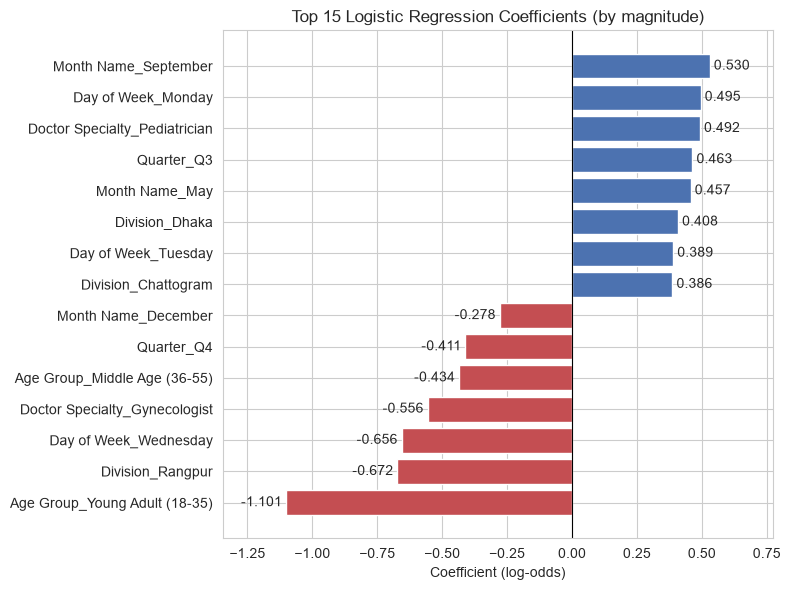

In [11]:
top_n = coef_df.head(15).copy()
top_n = top_n.reindex(top_n['coefficient'].sort_values().index)

fig, ax = plt.subplots(figsize=(8, 6))
ax.margins(x=0.15)
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in top_n['coefficient']]
bars = ax.barh(top_n['feature'], top_n['coefficient'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 15 Logistic Regression Coefficients (by magnitude)')
plt.tight_layout()
plt.show()

## Predicted Probabilities

Per the business question, the **primary output of this model is a probability**, not a hard
0/1 label. `predict_proba()` returns the probability of both classes.


In [12]:
proba_test = lr_model.predict_proba(X_test)

results = X_test.copy()
results['actual_no_show'] = Y_test.values
results['probability_show'] = proba_test[:, 0].round(3)      
results['probability_no_show'] = proba_test[:, 1].round(3)
results.sort_values('probability_no_show', ascending=False).head(10)

,Gender,Division,Doctor Specialty,Month Name,Quarter,Day of Week,Day Type,Age Group,Wait Days,actual_no_show,probability_show,probability_no_show
420,Female,Chattogram,Pediatrician,September,Q3,Monday,Weekday,Senior (56+),8,0,0.549,0.451
340,Male,Chattogram,Orthopedic,September,Q3,Tuesday,Weekday,Middle Age (36-55),19,1,0.552,0.448
19,Male,Dhaka,General Physician,September,Q3,Monday,Weekday,Senior (56+),12,1,0.591,0.409
65,Female,Dhaka,Orthopedic,September,Q3,Sunday,Weekday,Senior (56+),15,0,0.639,0.361
495,Male,Chattogram,Orthopedic,June,Q2,Monday,Weekday,Child (0-17),16,0,0.672,0.328
286,Female,Mymensingh,General Physician,September,Q3,Monday,Weekday,Senior (56+),17,0,0.702,0.298
410,Female,Chattogram,Dermatologist,May,Q2,Tuesday,Weekday,Child (0-17),13,0,0.712,0.288
108,Female,Dhaka,Orthopedic,March,Q1,Monday,Weekday,Child (0-17),11,0,0.755,0.245
24,Male,Sylhet,Pediatrician,August,Q3,Saturday,Weekend,Senior (56+),13,0,0.768,0.232
170,Male,Barishal,Dermatologist,September,Q3,Sunday,Weekday,Senior (56+),2,0,0.775,0.225


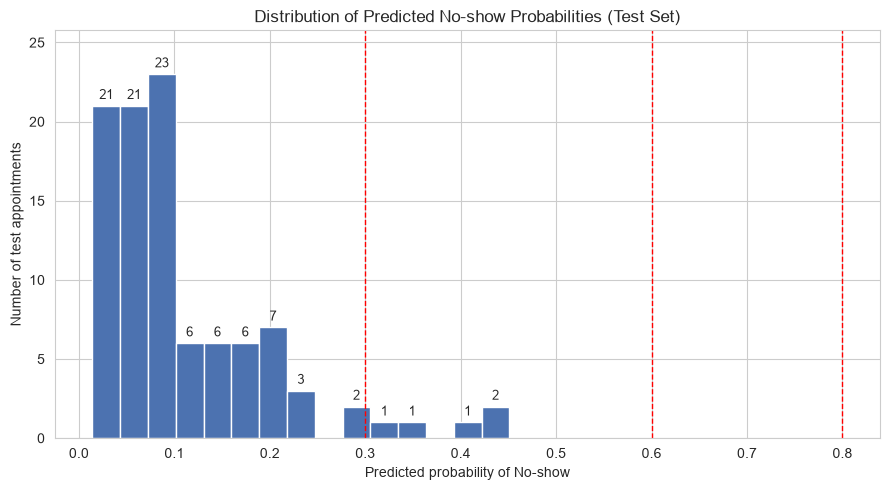

count    100.000
mean       0.112
std        0.092
min        0.014
25%        0.050
50%        0.082
75%        0.147
max        0.451
Name: probability_no_show, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
n, bins, patches = ax.hist(results['probability_no_show'], bins=15, color='#4C72B0', edgecolor='white')

labels = [str(int(count)) if count > 0 else '' for count in n]
ax.bar_label(patches, labels=labels, padding=3, fontsize=9)

for edge, label in zip([0.3, 0.6, 0.8], ['30%', '60%', '80%']):
    ax.axvline(edge, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted probability of No-show')
ax.set_ylabel('Number of test appointments')
ax.set_title('Distribution of Predicted No-show Probabilities (Test Set)')
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

print(pd.Series(results['probability_no_show'], name='probability_no_show').describe().round(3))

## Business Risk Categories

Converting the raw probability into categories a clinic scheduling team can act on, as
specified:

| Probability | Risk Category |
|---|---|
| 0% – 30% | Low |
| 30% – 60% | Moderate |
| 60% – 80% | High |
| 80% – 100% | Very High |


=== Risk Category Counts (Test Set) ===
risk_category
Low          95
Moderate      5
High          0
Very High     0
Name: count, dtype: int64


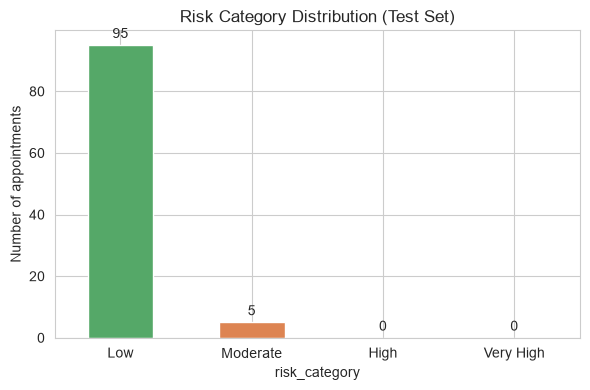

In [14]:
def risk_category(p):
    if p < 0.30:
        return 'Low'
    elif p < 0.60:
        return 'Moderate'
    elif p < 0.80:
        return 'High'
    else:
        return 'Very High'

results['risk_category'] = results['probability_no_show'].apply(risk_category)

category_order = ['Low', 'Moderate', 'High', 'Very High']
risk_counts = results['risk_category'].value_counts().reindex(category_order).fillna(0).astype(int)

print("=== Risk Category Counts (Test Set) ===")
print(risk_counts)

fig, ax = plt.subplots(figsize=(6, 4))
risk_counts.plot(kind='bar', ax=ax, color=['#55A868', '#DD8452', '#C44E52', '#8C0900'])
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylabel('Number of appointments')
ax.set_title('Risk Category Distribution (Test Set)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Model Evaluation

- **ROC-AUC** — measures how well the model separates No-show appointments from non-No-show appointments based on their predicted probabilities, considering different probability thresholds. 0.5 means the model performs no better than random ranking, while 1.0 means it perfectly separates the two groups.


In [15]:
roc_auc_lr = roc_auc_score(Y_test, results['probability_no_show'])

print(f"ROC-AUC   : {roc_auc_lr:.3f}")

ROC-AUC   : 0.595


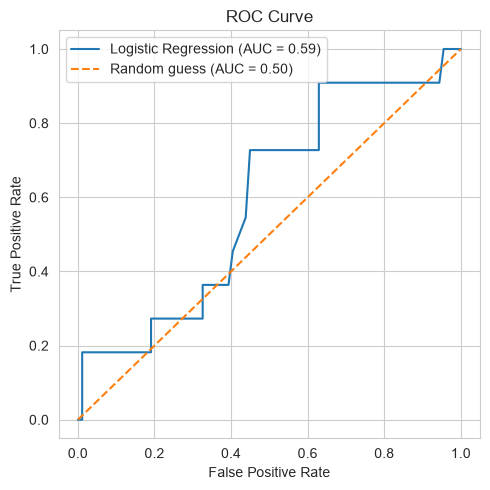

In [16]:
fpr, tpr, _ = roc_curve(Y_test, results['probability_no_show'])

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', label='Random guess (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

plt.tight_layout()
plt.show()

## Model Comparison — Decision Tree & Random Forest

Same features, same train/test split, same preprocessing. Only the classifier changes, so any ROC-AUC difference reflects the model, not the data.

In [17]:
dt_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ])),
    ('classifier', DecisionTreeClassifier(random_state=42)),
])
dt_model.fit(X_train, Y_train)

proba_dt = dt_model.predict_proba(X_test)[:, 1]
roc_auc_dt = roc_auc_score(Y_test, proba_dt)
print(f"Decision Tree ROC-AUC: {roc_auc_dt:.3f}")

Decision Tree ROC-AUC: 0.484


In [18]:
rf_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ])),
    ('classifier', RandomForestClassifier(random_state=42)),
])
rf_model.fit(X_train, Y_train)

proba_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(Y_test, proba_rf)
print(f"Random Forest ROC-AUC: {roc_auc_rf:.3f}")

Random Forest ROC-AUC: 0.531


In [19]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'ROC-AUC': [roc_auc_lr, roc_auc_dt, roc_auc_rf]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

comparison

,Model,ROC-AUC
0,Logistic Regression,0.594995
1,Random Forest,0.530644
2,Decision Tree,0.483657


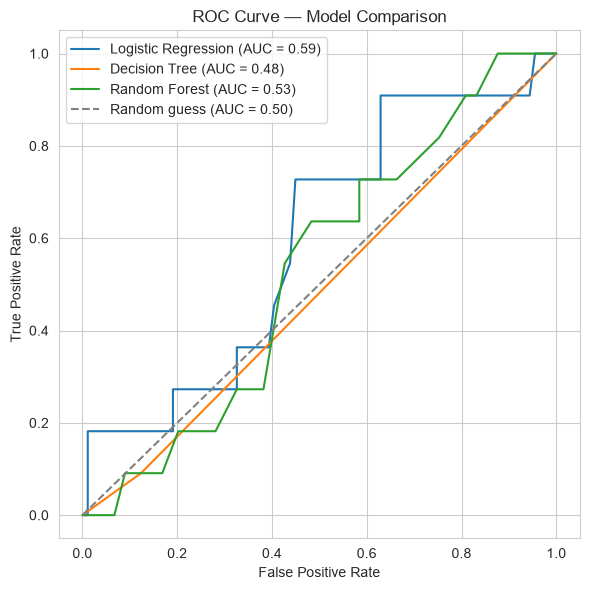

In [20]:
fpr_lr, tpr_lr, _ = roc_curve(Y_test, results['probability_no_show'])
fpr_dt, tpr_dt, _ = roc_curve(Y_test, proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, proba_rf)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Logistic Regression achieved the highest ROC-AUC on the baseline test set (**0.59**), followed by Random Forest (**0.53**) and Decision Tree (**0.48**). These results use each model's default settings, evaluated on a single train/test split.

> **Note:** Because the dataset is small, the observed ROC-AUC can vary substantially depending on the train/test split. These baseline results therefore serve as a reference point for evaluating whether hyperparameter tuning improves the model's generalization performance.

## Model Improvement — Class Imbalance Handling & Hyperparameter Tuning

Testing whether `GridSearchCV` hyperparameter tuning (Logistic Regression, Decision Tree, Random Forest) improve on the baseline ROC-AUC scores above.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {
    'classifier__C': [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1],
    'classifier__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    lr_model,
    param_grid_lr,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, Y_train)

lr_tuned_model = grid_lr.best_estimator_

proba_lr_tuned = lr_tuned_model.predict_proba(X_test)[:, 1]

roc_auc_lr_tuned = roc_auc_score(Y_test, proba_lr_tuned)

print("=== Logistic Regression Tuning Results ===")
print(f"Before Tuning ROC-AUC: {roc_auc_lr:.3f}")
print(f"After Tuning ROC-AUC: {roc_auc_lr_tuned:.3f}")
print(f"Best Parameters: {grid_lr.best_params_}")

=== Logistic Regression Tuning Results ===
Before Tuning ROC-AUC: 0.595
After Tuning ROC-AUC: 0.584
Best Parameters: {'classifier__C': 0.003, 'classifier__class_weight': 'balanced'}


In [22]:
# Decision Tree — GridSearchCV:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_dt = {
    'classifier__max_depth': [3, 5, 6, 7, 8, 10, None],
    'classifier__min_samples_leaf': [2, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(dt_model, param_grid_dt, scoring='roc_auc', cv=cv, n_jobs=-1)
grid_dt.fit(X_train, Y_train)

dt_tuned_model = grid_dt.best_estimator_
proba_dt_tuned = dt_tuned_model.predict_proba(X_test)[:, 1]
roc_auc_dt_tuned = roc_auc_score(Y_test, proba_dt_tuned)

print("=== Decision Tree Tuning Results ===")

print(f"Before Tuning ROC-AUC: {roc_auc_dt:.3f}")
print(f"After Tuning ROC-AUC: {roc_auc_dt_tuned:.3f}")
print(f"Best Parameters: {grid_dt.best_params_}")

=== Decision Tree Tuning Results ===
Before Tuning ROC-AUC: 0.484
After Tuning ROC-AUC: 0.574
Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}


In [23]:
# Random Forest — GridSearchCV:
param_grid_rf = {
    'classifier__n_estimators': [80, 90, 100],
    'classifier__max_depth': [6, 7, 8],
    'classifier__min_samples_leaf': [1, 2, 3],
    'classifier__class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(rf_model, param_grid_rf, scoring='roc_auc', cv=cv, n_jobs=-1)
grid_rf.fit(X_train, Y_train)

rf_tuned_model = grid_rf.best_estimator_
proba_rf_tuned = rf_tuned_model.predict_proba(X_test)[:, 1]
roc_auc_rf_tuned = roc_auc_score(Y_test, proba_rf_tuned)

print("=== Random Forest Tuning Results ===")

print(f"Before Tuning ROC-AUC: {roc_auc_rf:.3f}")
print(f"After Tuning ROC-AUC: {roc_auc_rf_tuned:.3f}")
print(f"Best Parameters: {grid_rf.best_params_}")

=== Random Forest Tuning Results ===
Before Tuning ROC-AUC: 0.531
After Tuning ROC-AUC: 0.588
Best Parameters: {'classifier__class_weight': None, 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 80}


In [24]:
improvement_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Baseline ROC-AUC': [roc_auc_lr, roc_auc_dt, roc_auc_rf],
    'Tuned ROC-AUC': [roc_auc_lr_tuned, roc_auc_dt_tuned, roc_auc_rf_tuned],
})
improvement_comparison['Improved?'] = improvement_comparison['Tuned ROC-AUC'] > improvement_comparison['Baseline ROC-AUC']

improvement_comparison

,Model,Baseline ROC-AUC,Tuned ROC-AUC,Improved?
0,Logistic Regression,0.594995,0.584270,False
1,Decision Tree,0.483657,0.573544,True
2,Random Forest,0.530644,0.588355,True


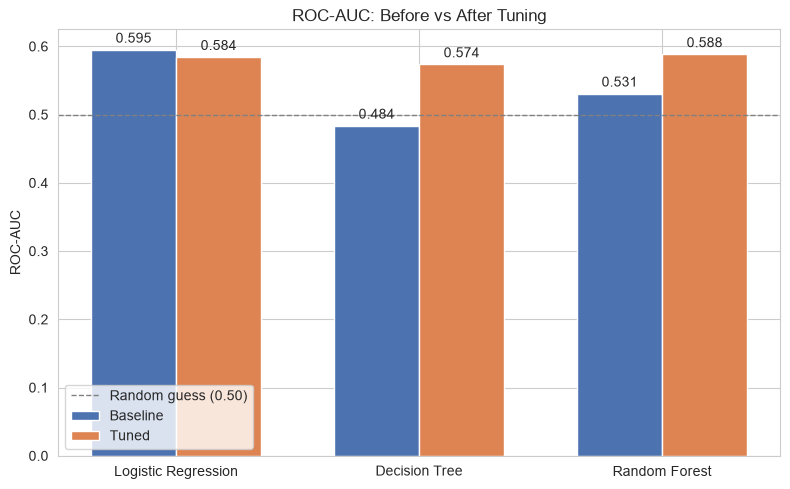

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(improvement_comparison))
width = 0.35

bars_baseline = ax.bar(x - width/2, improvement_comparison['Baseline ROC-AUC'], width, label='Baseline', color='#4C72B0')
bars_tuned = ax.bar(x + width/2, improvement_comparison['Tuned ROC-AUC'], width, label='Tuned', color='#DD8452')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random guess (0.50)')

ax.bar_label(bars_baseline, fmt='%.3f', padding=3)
ax.bar_label(bars_tuned, fmt='%.3f', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(improvement_comparison['Model'])
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC: Before vs After Tuning')
ax.legend()
plt.tight_layout()
plt.show()

## Final Model Selection

The baseline models were first evaluated using one fixed train/test split, with default settings for each classifier. Logistic Regression achieved the highest ROC-AUC of **0.595**, followed by Random Forest at **0.531** and Decision Tree at **0.484**.

The models were then tuned using **cross-validation**. Instead of judging a model from one split, cross-validation tests each model configuration on multiple training and validation splits. This gives a better idea of how consistently the model performs on different data.

After tuning, the test-set ROC-AUC scores were **0.584** for Logistic Regression, **0.574** for Decision Tree, and **0.588** for Random Forest, higher than the baseline results for the tree models. This is a genuine finding rather than a failed attempt: with only 56 No-show cases in the dataset, cross-validation itself is noisy, and the small sample size limits how much tuning can improve on a reasonable default configuration.

For the final model, the **tuned Random Forest** is selected because it achieved the highest ROC-AUC after tuning. The tuning process also provides a more systematic model configuration based on performance across multiple validation splits, rather than relying on a single train/test split.

## Limitations

* **Small dataset:** The dataset contains only 500 appointments, including 56 No-shows. With a small number of positive cases, ROC-AUC can change considerably depending on which records are included in the training and test sets.

* **Limited predictive signal:** The final tuned models achieved ROC-AUC values between **0.574 and 0.588**. This indicates that the current features provide only limited ability to separate No-shows from future appointments.

* **Limited features:** Important behavioral and historical information such as reminder history, travel distance is unavailable. These factors could provide stronger signals for prediction.

* **Limited generalizability:** The dataset represents a relatively small sample from a specific period and may not fully represent appointment behavior across different hospitals, regions, patient groups, or time periods.

* **Further validation needed:** A larger dataset and additional validation would be needed before using the model for real-world healthcare decisions.

## Conclusion

This project extended the healthcare appointment analysis from descriptive analytics to predictive analytics by testing whether the available data could be used to identify appointments that may result in a No-show.

Three classification approaches — Logistic Regression, Decision Tree, and Random Forest were compared, followed by hyperparameter tuning using cross-validation. The tuned Random Forest achieved the highest ROC-AUC among the tuned models, with a score of **0.588**.

The results show that the current data provides some limited information about No-show behavior, so not enough for reliable prediction. This means the current model should not be relied upon for real-world decisions. A larger dataset with additional information, such as reminder history and travel distance, could help determine whether more reliable No-show prediction is possible.

Overall, the analysis demonstrates a complete process of testing the feasibility of predictive modeling for a real business problem, from baseline modeling and model comparison to tuning and final model evaluation. It also shows that when the available data is not sufficient for reliable prediction, identifying the missing information is an important outcome for future analysis.